In [28]:
!pip install transformers
!pip install tqdm

In [29]:
import requests
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn

from PIL import Image

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from transformers import BertTokenizer
from transformers import BertModel

from torchvision import models
from torchvision import transforms

In [30]:
torch.manual_seed(42)
np.random.seed(42)

In [31]:
import zipfile
import os


with zipfile.ZipFile("fakeddit.zip", "r") as zip_ref:
    zip_ref.extractall("multimodal_only_samples")

train_dataset = pd.read_csv("multimodal_only_samples/multimodal_only_samples/multimodal_train.tsv", sep="\t")
train_dataset.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


In [32]:
#choosing subset columns text input, image input, fake/real label and keeping first 1000
#.dropna() removes NaN rows
subset_dataset = train_dataset[ ["clean_title", "image_url", "2_way_label"]].dropna()

subset_dataset = subset_dataset.iloc[:10000]

print(subset_dataset.shape)

(10000, 3)


In [33]:
#making a folder fakeddit_images to store downloaded images
os.makedirs("fakeddit_images", exist_ok=True)

downloaded_paths = []

for index, row in tqdm( subset_dataset.iterrows(), total=len(subset_dataset) ):

  try :
    image_url = row["image_url"]

    image_path = (f"fakeddit_images/{index}.jpg")

    #python sends an HTTP request to the URL to download image
    response = requests.get( image_url, timeout=10 )

    #check if download succeeded, write image bytes to disk and resuling image stored
    #200 -> success, 404 -> not found, 500 -> server error
    if response.status_code == 200 :

        with open( image_path, "wb" ) as file:
            file.write(response.content)

        downloaded_paths.append(image_path)

    else :
      downloaded_paths.append(None)

  except:
      downloaded_paths.append(None)


#adding image path col to dataset
subset_dataset["image_path"] = downloaded_paths

subset_dataset = subset_dataset.dropna()

print(subset_dataset.shape)

100%|██████████| 10000/10000 [43:41<00:00,  3.81it/s]

(6663, 4)


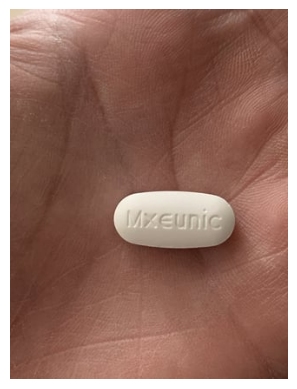

In [34]:
sample_image = Image.open( subset_dataset["image_path"].iloc[0] )

plt.imshow(sample_image)
plt.axis("off")
plt.show()

In [35]:
#downloads tokenizer for bert
bert_tokenizer = BertTokenizer.from_pretrained( "bert-base-uncased" )

#loading actual bert model, .eval() for deterministic results each time
bert_model = BertModel.from_pretrained( "bert-base-uncased" )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
#text feature extraction (text -> bert -> 768 features)
def extracting_text_features(text):

  #converting text to bert input
  tokens = bert_tokenizer(
      text,
      return_tensors="pt",
      truncation=True,
      padding=True,
      max_length=128 )

  #converting to embeddings
  with torch.no_grad():

    outputs = bert_model(**tokens)

  #extracting cls embedding (bert uses cls to summarize the entire sentence)
  cls_embedding = ( outputs.last_hidden_state[:,0,:] )

  return cls_embedding.squeeze(0).numpy()

In [37]:
#image feature extraction through pretrained ResNet50
resnet_model = models.resnet50( pretrained=True )

for param in resnet_model.parameters():
  param.requires_grad = False


#remove final output and just keep features
feature_extractor = nn.Sequential( *list(resnet_model.children())[:-1] )

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [38]:
#transform pipeline to convert raw image to exact format expected by pretrained resnet50
transform = transforms.Compose([
    transforms.Resize((224,224)) ,
    transforms.ToTensor() ,
    transforms.Normalize( mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225] )
] )


#img feature extraction (image -> resnet50 -> 2048 features)
def extracting_image_features(path):

  image = Image.open(path).convert("RGB")

  tensor = transform(image)

  tensor = tensor.unsqueeze(0)

  with torch.no_grad():
    features = feature_extractor(tensor)

  return features.view(-1).numpy()

In [44]:
text_features = []
image_features = []
labels = []

for i, row in tqdm(subset_dataset.iterrows(), total=len(subset_dataset)):

  try:

    text_vector = extracting_text_features( row["clean_title"] )

    image_vector = extracting_image_features( row["image_path"] )

    label = row["2_way_label"]

    #append only after everything succeeds
    text_features.append(text_vector)
    image_features.append(image_vector)
    labels.append(label)

  except Exception as e:
    print(f"Failed sample {i}: {e}")

 41%|████      | 2706/6663 [17:18<23:38,  2.79it/s]

Failed sample 4107: cannot identify image file 'fakeddit_images/4107.jpg'


 81%|████████  | 5389/6663 [34:02<07:06,  2.99it/s]

Failed sample 8131: cannot identify image file 'fakeddit_images/8131.jpg'


100%|██████████| 6663/6663 [41:59<00:00,  2.64it/s]


In [45]:
text_features = np.array(text_features)

image_features = np.array(image_features)

labels = np.array(labels)

print(text_features.shape)

print(image_features.shape)

(6661, 768)
(6661, 2048)


In [47]:
X_text_train, X_text_test, X_image_train, X_image_test, y_train, y_test = train_test_split(
    text_features,
    image_features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels)

In [48]:
from sklearn.preprocessing import StandardScaler

text_scaler = StandardScaler()
image_scaler = StandardScaler()

X_text_train = text_scaler.fit_transform(X_text_train)
X_text_test = text_scaler.transform(X_text_test)

X_image_train = image_scaler.fit_transform(X_image_train)
X_image_test = image_scaler.transform(X_image_test)

In [49]:
class AttentionFusion(nn.Module):

    def __init__(self):
      super().__init__()

      #convrting 768/2048 features to 256 features to put in common feature space
      self.text_layer = nn.Linear( 768, 256 )

      self.image_layer = nn.Linear( 2048, 256 )

      #converting 256+256=512 to 2 text importance and img importance
      self.attention = nn.Linear( 512, 2 )

      self.classifier = nn.Sequential(
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128,2) )

    def forward(self, text, image) :
      #process text
      text_hidden = self.text_layer(text)

      #process image
      image_hidden = self.image_layer(image)

      #concatenate
      combined = torch.cat( [text_hidden, image_hidden], dim=1 )

      #compute attention
      attention_weights = torch.softmax( self.attention(combined), dim=1 )

      #extract weight of text and image
      text_weight = (attention_weights[:,0].unsqueeze(1) )

      image_weight = ( attention_weights[:,1].unsqueeze(1) )

      #fusion
      fused = (text_weight * text_hidden + image_weight * image_hidden )

      output = self.classifier( fused )

      return output, attention_weights

Pipeline:
Title -> BERT -> 768 -> Linear -> 256 -> Attention -> Text Weight

Image -> ResNet50 -> 2048 -> Linear -> 256 -> Attention -> Image Weight

TextWeight * TextFeature + ImageWeight * ImageFeature -> Fused Vector -> Classifier -> Fake/Real

Attention learns importance of each of the models

In [50]:
#converting to tensors
X_text_train = torch.tensor( X_text_train, dtype=torch.float32 )

X_text_test = torch.tensor( X_text_test, dtype=torch.float32 )

X_image_train = torch.tensor( X_image_train, dtype=torch.float32 )

X_image_test = torch.tensor( X_image_test, dtype=torch.float32 )

y_train = torch.tensor( y_train, dtype=torch.long )

y_test = torch.tensor( y_test, dtype=torch.long )

In [51]:
model = AttentionFusion()

#loss function and adam optimizer
loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001 )

1. Instantiate attention based multimodal classifier
2. define CrossEntropyLoss as loss function
3. Adam optimizer for updating model's trainable parameters during training to minimize classification error

In [52]:
outputs, attention = model(
    X_text_train[:5] ,
    X_image_train[:5] )

print(outputs.shape)

print(attention.shape)

torch.Size([5, 2])
torch.Size([5, 2])


In [53]:
epochs = 20

loss_log = []

for i in range(0, epochs):

  #train the model and clear old gradiants
  model.train()
  optimizer.zero_grad()

  #training samples through forward pass
  outputs, attention = model(
    X_text_train,
    X_image_train
  )

  #comparing predicted with actual
  current_loss = loss(outputs, y_train )

  #backpropgation used to see which weight caused error and then update it
  current_loss.backward()
  optimizer.step()

  loss_log.append( current_loss.item() )

  print(f"Epoch {i+1}/{epochs}", "Loss:", current_loss.item() )


Epoch 1/20 Loss: 0.6865798830986023
Epoch 2/20 Loss: 0.6180152297019958
Epoch 3/20 Loss: 0.5572932362556458
Epoch 4/20 Loss: 0.49877628684043884
Epoch 5/20 Loss: 0.44542261958122253
Epoch 6/20 Loss: 0.39685171842575073
Epoch 7/20 Loss: 0.3522275686264038
Epoch 8/20 Loss: 0.31375008821487427
Epoch 9/20 Loss: 0.279710590839386
Epoch 10/20 Loss: 0.24783508479595184
Epoch 11/20 Loss: 0.21791855990886688
Epoch 12/20 Loss: 0.19052980840206146
Epoch 13/20 Loss: 0.16552679240703583
Epoch 14/20 Loss: 0.1431782990694046
Epoch 15/20 Loss: 0.12304917722940445
Epoch 16/20 Loss: 0.1051921471953392
Epoch 17/20 Loss: 0.08905632793903351
Epoch 18/20 Loss: 0.07405136525630951
Epoch 19/20 Loss: 0.061133623123168945
Epoch 20/20 Loss: 0.05024189502000809


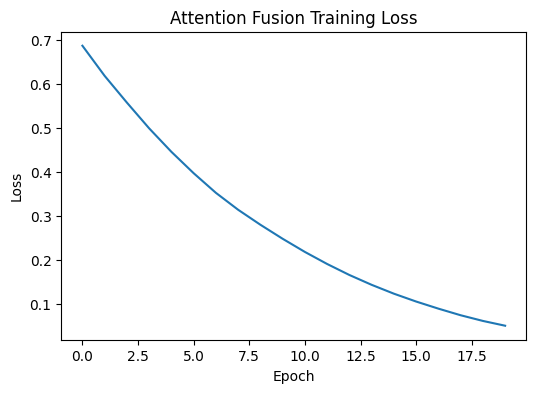

In [54]:
plt.figure(figsize=(6,4))
plt.plot(loss_log)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Attention Fusion Training Loss")
plt.show()

After each epoch due to backpropogation, each weight is checked due to which error is caused and its weight is adjusted.
Hence, this results in total loss being reduced at each step.

In [55]:
#now to stop training and start evaluation, hence disable gradiant computation as well
model.eval()

with torch.no_grad() :

  outputs, attention = model(X_text_test, X_image_test )
  predictions = torch.argmax(outputs, dim=1)


accuracy = accuracy_score(y_test.numpy(), predictions.numpy() )

torch.save({'model_state_dict': model.state_dict(), 'accuracy': accuracy}, 'attention_fusion_model.pth')

print("Accuracy of prediction :", accuracy )

torch.save(
    {
      'model_state_dict': model.state_dict(),
      'accuracy': accuracy
    }, 'attention_fusion_model.pth'
)

Accuracy of prediction : 0.6946736684171043


In [56]:
print(classification_report(
      y_test.numpy(),
      predictions.numpy() ) )

              precision    recall  f1-score   support

           0       0.64      0.66      0.65       579
           1       0.74      0.72      0.73       754

    accuracy                           0.69      1333
   macro avg       0.69      0.69      0.69      1333
weighted avg       0.70      0.69      0.70      1333



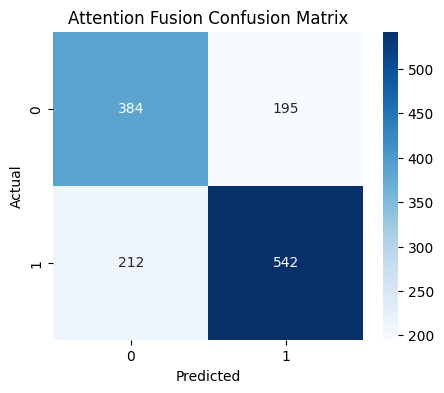

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

confusion_mat = confusion_matrix( y_test.numpy(), predictions.numpy() )

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_mat,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Attention Fusion Confusion Matrix" )
plt.show()

In [58]:
with torch.no_grad():
  i, attention = model(X_text_test[:10], X_image_test[:10])

print(attention)

tensor([[0.2605, 0.7395],
        [0.9065, 0.0935],
        [0.8343, 0.1657],
        [0.2339, 0.7661],
        [0.4541, 0.5459],
        [0.2043, 0.7957],
        [0.9969, 0.0031],
        [0.4710, 0.5290],
        [0.3375, 0.6625],
        [0.1051, 0.8949]])
